## Seaborn: Working with large amount of Datapoints

In this notebook we will be working with a dataset that contains genome sequence assembly data. At times, when you are working with a dataset that has a large number of data points it can be hard to see the nunances that get hidden when many of the datapoints have similar values. We will address how to better visualize this cases in this notebook.

<table border=0><tr>
<td colspan=2><img src="https://rheonix.com/wp-content/uploads/2018/10/Updated-NGS-Workflow-web.png" width=700></td></tr>
<tr><td><img src="https://contig.files.wordpress.com/2010/02/alignment.jpg" width=400></td><td>
<img src="https://slideplayer.com/slide/12967081/79/images/6/Sequence+assembly+Reads+Contigs+Scaffolds+6.jpg" width=300></td></tr></table>

In [6]:
### Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
### This dataset has no missing data
contigs_filepath="https://raw.githubusercontent.com/csbfx/advpy122-data/master/contigs.csv"

contigs = pd.read_csv(contigs_filepath)
contigs.head()

,name,length,GC,coverage,phylum
0,scaffold1_size1534183,1534183,0.4304,0.603315,Bacteroidetes
1,scaffold2_size1255804,1255804,0.4237,1.266944,Bacteroidetes
2,scaffold3_size1208507,1208507,0.5007,0.364660,Armatimonadetes
3,scaffold4_size1204010,1204010,0.4281,0.499764,Bacteroidetes
4,scaffold5_size1189196,1189196,0.4942,0.320681,Proteobacteria


In [10]:
### How many datapoints are there in this dataset? That is how many rows?
## Two ways to get this information; 1. shape 2. info()
contigs.shape
contigs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22497 entries, 0 to 22496
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      22497 non-null  object 
 1   length    22497 non-null  int64  
 2   GC        22497 non-null  float64
 3   coverage  22497 non-null  float64
 4   phylum    22497 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 878.9+ KB


### `relplot` to visualize scatter plot
Let’s try to visualize the relationship between "GC" (GC content) and "length" (note that for this dataset the GC is measured as a content ranging between 0 and 1).

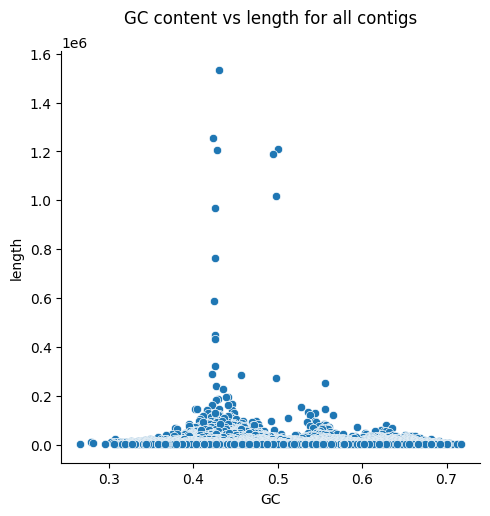

In [ ]:
### Plot the relationship between "GC" and "length"
gc = sns.relplot(data=contigs, x="GC", y="length")
plt.title("GC content vs length for all contigs", pad=20); #pad=20, allow a bit more space for a two-line title

### Remove outlier from visualization
Let's re-visualize our plot by first filtering out for some outliers (ie., small numbers of very large contigs). We will use pandas to filter these out in order to better see the distribution of the rest of the data.

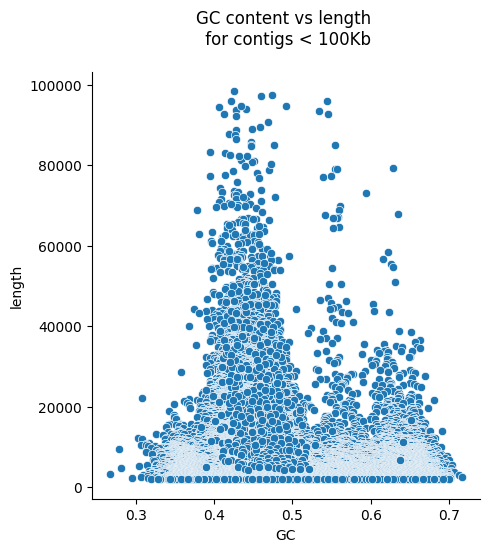

In [11]:
### Filter out in relplot contigs with length less than 100000
sns.relplot(
    data = contigs[contigs.length < 100000],
    x = "GC",
    y = "length"
)
plt.title("GC content vs length \n for contigs < 100Kb", pad=20);

### Altering the transparency of the data points
There is clearly some structure in this plot, but the sheer number of points being plotted make it hard to see. There are simply too many points on top of each other.

There are a few ways to cope with this. One option is to set the points to be transparent using the `alpha` argument. Setting `alpha = 0.01` makes the each point on the plot 99% transparent and turns the circles into a fuzzy cloud, and makes it possible to discern some structure that we could not see before.

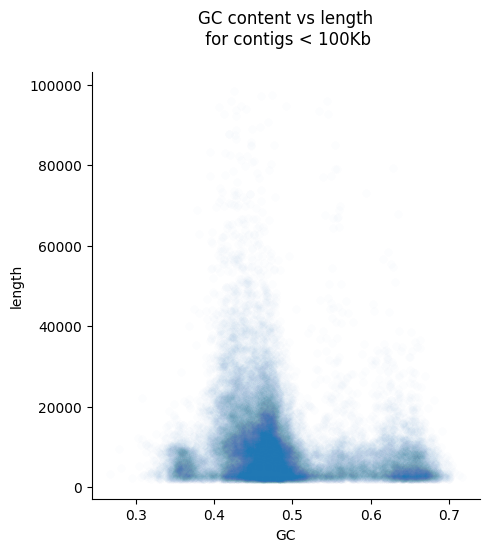

In [12]:
sns.relplot(
    data = contigs[contigs.length < 100000],
    x = "GC",
    y = "length",
    alpha = 0.01
)
plt.title("GC content vs length\n for contigs < 100Kb", pad=20);

### Changing size of data points
It certainly looks like there are several populations of contigs with different ranges of GC and length.

A similar idea is to shrink the points, which we can do by setting the `s` parameter (`s` is short for size - remember from earlier that the size parameter is used when we want the size of points to vary). We will also have to remove the border around each point by setting its `linewidth` to zero:

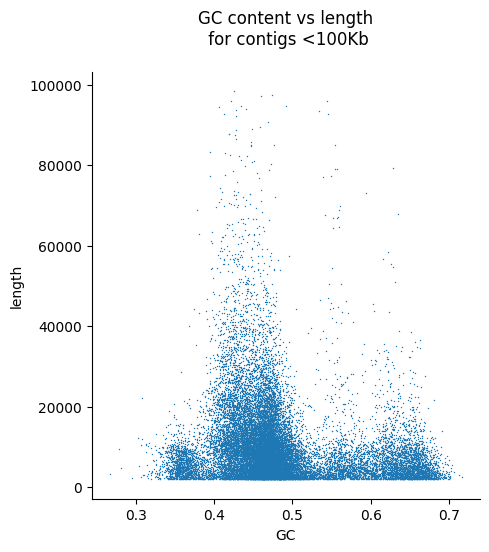

In [13]:
sns.relplot(
    data=contigs[contigs.length < 100000],
    x="GC",
    y="length",
    s=1,
    linewidth=0
)
plt.title("GC content vs length\n for contigs <100Kb", pad=20);

### Subsampling
Another option when we have too many points is to plot just a random subset of the dataset. There is no option to do that in seaborn, but luckily it is easy using pandas.

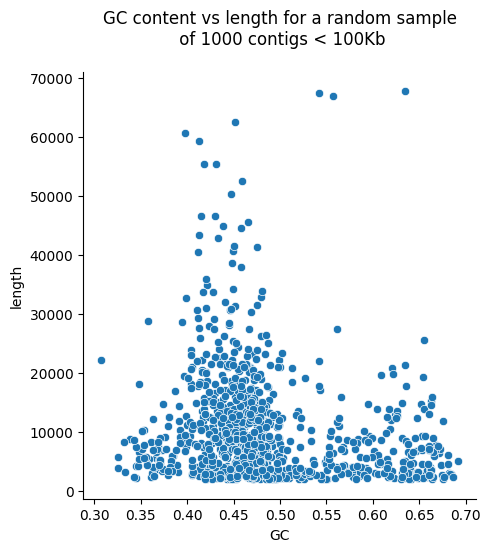

In [ ]:
### Subsample the dataset to select a random subset
sns.relplot(
    data=contigs[contigs.length < 100000].sample(1000),
    x="GC",
    y="length"

plt.title(
    "GC content vs length for a random sample\n of 1000 contigs < 100Kb", pad=20)
;

## Hexbin
These first three approaches still use scatter plots, where individual data points are drawn. To get away from this, we could imagine dividing up the area of the chart into different regions and shading them based on the number of
points in the area. This gives us a **hexbin** chart. We can draw one in seaborn using`jointplot()` with the `kind=hex` argument.

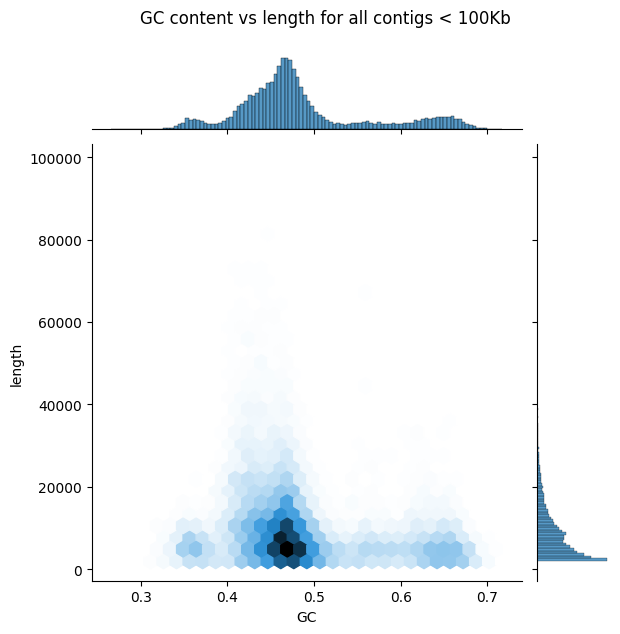

In [14]:
fig = sns.jointplot(
    data=contigs[contigs.length < 100_000],
    x = "GC",
    y = "length",
    kind = "hex",
    gridsize = 30 #how many hexes wide and high
)

### Set a super title for the figure
# Notice how for this plot, our usual approach of using plt.title to set a title doesn’t work
# We will use the fig attribute to get a reference to the figure, then call suptitle to make a supertitle

fig.fig.suptitle("GC content vs length for all contigs < 100Kb", y = 1.05); # y = 1.05 is the coordinate
                                                                          # where the title is positioned

### Limitation of hexbin
This hexbin plot nicely illustrates one of its weaknesses; the outliers with large size effectively disappear from the chart. The reason why is that there are not enough data points in any one hex to raise its density above the background level. This is a fundamental trade off that we see in many types of plots. To visualize large datasets generally means that we need to give up on the ability to see individual points.

Given that we cannot actually see any data above about 40000 on the y-axis, we will focus on the data that we can see by excluding contigs with length greater than 40000.

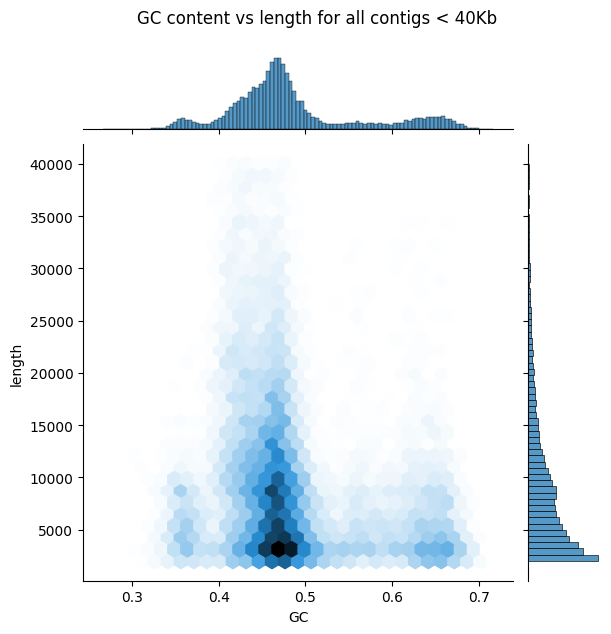

In [ ]:
## Plot contigs less than 40Kb
g = sns.jointplot(
    data = contigs[contigs.length < 40000],
    x = "GC",
    y = "length",
    kind = "hex",
    gridsize = 30
)

# Set a super title for the figure
g.fig.suptitle("GC content vs length for all contigs < 40Kb", y = 1.05);

# Class exercise

## **Class Exercise CL8.1**
To visualize and identify clusters of species with similar genome-to-protein size relationships and where the data is most dense, use a hexbin plot using `jointplot(kind="hex")` function. Plot `Size (Mb)` on the x-axis and `Number of protein` on the y-axis. You can choose the gridsize. Include a title for the plot. After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Size (Mb)` and `Number of protein`, what else does this plot show?

&nbsp;  
**Here is your answer for CL8.2**

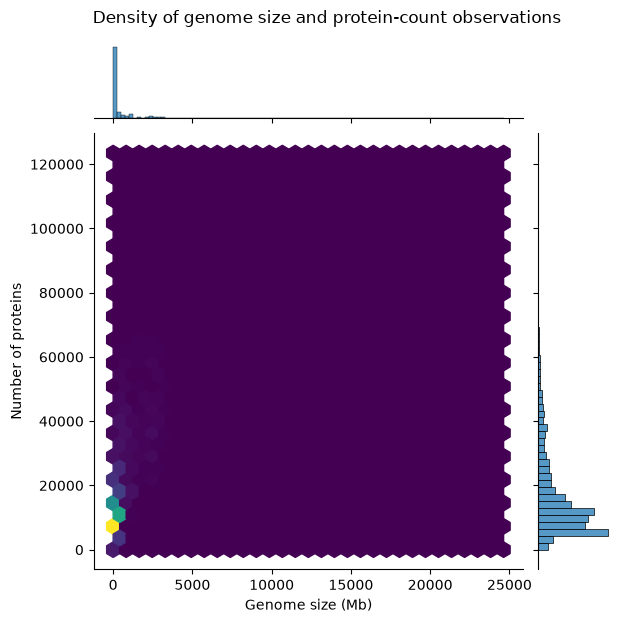

In [11]:
# Your code

euk = pd.read_csv('https://raw.githubusercontent.com/csbfx/advpy122-data/master/euk.tsv',
                  sep='\t', na_values='-')
genomes = euk.dropna(subset=['Size (Mb)', 'Number of proteins'])
g = sns.jointplot(data=genomes, x='Size (Mb)', y='Number of proteins',
                  kind='hex', gridsize=30, cmap='viridis')
g.set_axis_labels('Genome size (Mb)', 'Number of proteins')
g.fig.suptitle('Density of genome size and protein-count observations', y=1.03)
plt.show()


The position of each hexagon represents a range of genome sizes and protein counts, while its color represents how many records fall in that range. This reveals dense concentrations and sparse areas that can be hidden by overlapping scatter points; the marginal histograms show each variable's distribution. The broad tendency is toward more proteins in larger genomes, with considerable variation. A dense hexagon is a concentration of records, not evidence on its own of a distinct biological group, and sparse outliers can be hard to see.


## **Class Exercise CL8.2**
To compare across kingdoms side-by-side, use a multi-panel grid. Use `relplot(kind="scatter", col="Kingdom", hue="Class")` to produce multiple scatter plots of genome size versus `Number of genes` separated by `Kingdom`.

** To create a multi-panel grid, use the `col` and `row` parameters, which assign categorical variables to the columns and rows of the grid, respectively.

&nbsp;  
**Here is your answer for CL8.4**

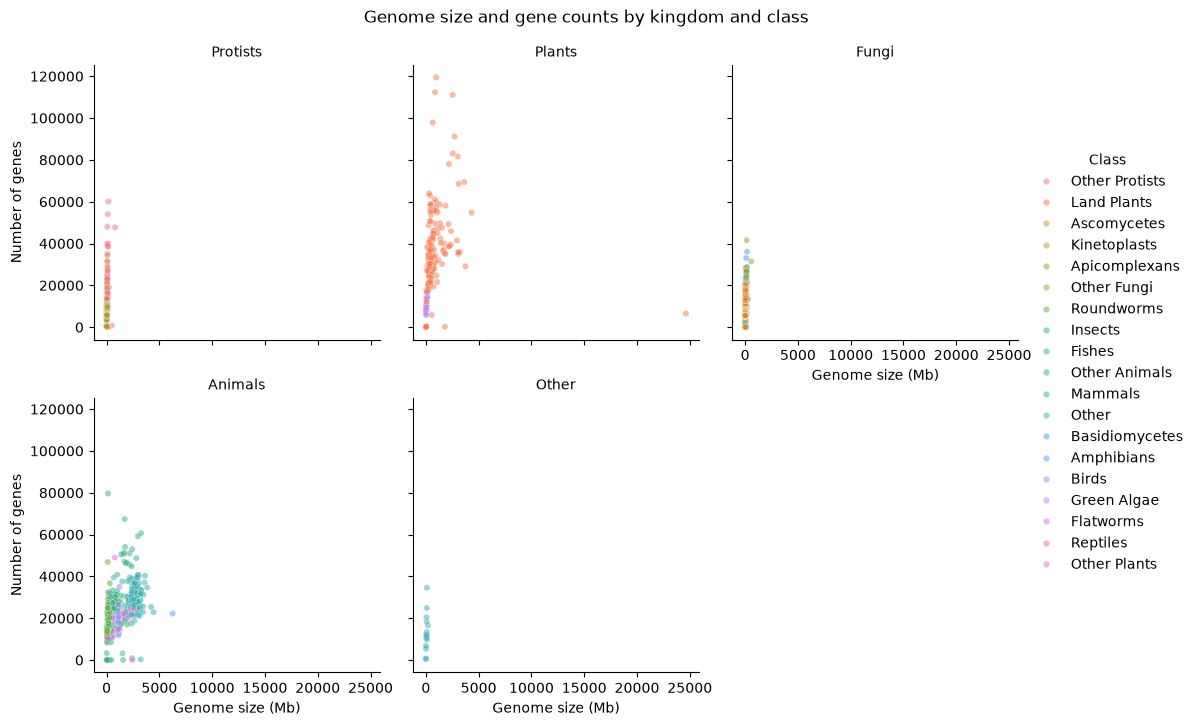

In [12]:
# Your code

g = sns.relplot(data=euk.dropna(subset=['Size (Mb)', 'Number of genes', 'Kingdom', 'Class']),
                x='Size (Mb)', y='Number of genes', kind='scatter',
                col='Kingdom', col_wrap=3, hue='Class', alpha=0.5, s=20,
                height=3.5, facet_kws={'sharex': True, 'sharey': True})
g.set_axis_labels('Genome size (Mb)', 'Number of genes')
g.set_titles('{col_name}')
g.fig.suptitle('Genome size and gene counts by kingdom and class', y=1.03)
plt.show()


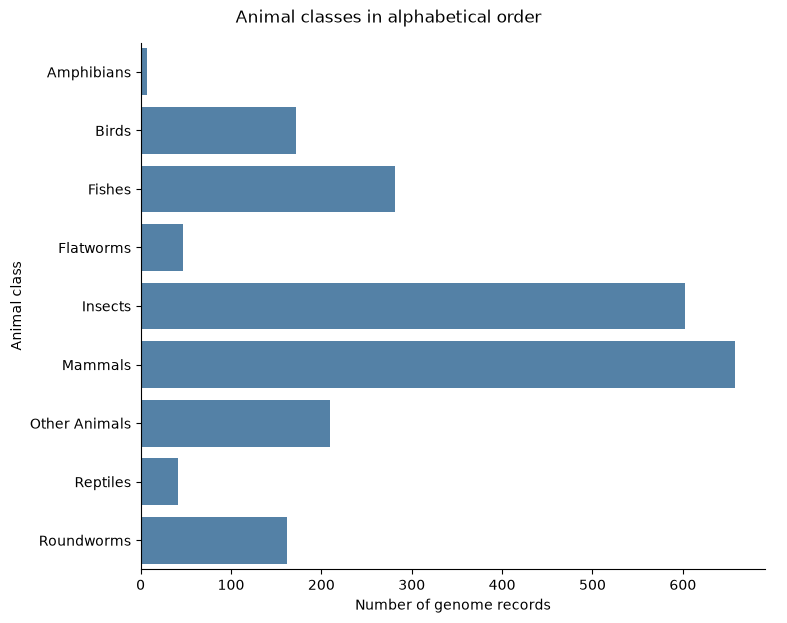

In [13]:
# Additional challenge: Modify the plot above to display the barplot where the classes of animals are displayed in alphabetical order.

animal_classes = euk.loc[euk['Kingdom'] == 'Animals', ['Class']].dropna()
alphabetical_order = sorted(animal_classes['Class'].unique())
g = sns.catplot(data=animal_classes, y='Class', kind='count',
                order=alphabetical_order, color='steelblue', height=6, aspect=1.3)
g.set_axis_labels('Number of genome records', 'Animal class')
g.fig.suptitle('Animal classes in alphabetical order', y=1.03)
plt.show()
